# 05 - Análisis Final e Integración

Integración de todos los resultados, conclusiones finales y propuestas para trabajo futuro.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from data_preprocessing import load_processed_data, encode_categorical_features
from model_evaluation import load_all_models, generate_final_summary

sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 12

## 1. Carga de Datos y Modelos

In [6]:
# Cargar datos
df = load_processed_data()
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

# Preparar datos
X_encoded, _ = encode_categorical_features(X)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cargar modelos originales y optimizados
models_dir = os.path.join(os.path.dirname(os.getcwd()), 'models', 'trained_models')
all_models = load_all_models(models_dir)

print(f'Modelos disponibles: {len(all_models)}')
print(f'Nombres: {list(all_models.keys())}')

Columnas codificadas: 16
Cargado: Decision Tree Optimized
Cargado: Decision Tree
Cargado: Gradient Boosting Optimized
Cargado: Gradient Boosting
Cargado: Knn
Cargado: Logistic Regression Optimized
Cargado: Logistic Regression
Cargado: Naive Bayes
Cargado: Random Forest Optimized
Cargado: Random Forest
Cargado: Svm
Modelos disponibles: 11
Nombres: ['Decision Tree Optimized', 'Decision Tree', 'Gradient Boosting Optimized', 'Gradient Boosting', 'Knn', 'Logistic Regression Optimized', 'Logistic Regression', 'Naive Bayes', 'Random Forest Optimized', 'Random Forest', 'Svm']


## 2. Comparación Final: Modelos Originales vs Optimizados

In [7]:
# Cargar métricas anteriores
metrics_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'metrics')

try:
    original_results = pd.read_csv(os.path.join(metrics_dir, 'model_comparison_results.csv'), index_col=0)
    optimized_results = pd.read_csv(os.path.join(metrics_dir, 'hyperparameter_tuning_results.csv'), index_col=0)
    
    print('Modelos Originales:')
    print(original_results.to_string())
    
    print('\n\nModelos Optimizados:')
    print(optimized_results.to_string())
except:
    print('Archivos de métricas no encontrados. Ejecutar notebooks anteriores primero.')

Modelos Originales:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.990      1.000  0.9899    0.9949   0.9949
Decision Tree           1.000      1.000  1.0000    1.0000   1.0000
Random Forest           0.990      0.990  1.0000    0.9950   0.5000
Gradient Boosting       0.990      0.990  1.0000    0.9950   0.5000
SVM                     0.990      0.990  1.0000    0.9950   0.5000
KNN                     0.990      0.990  1.0000    0.9950   0.5000
Naive Bayes             0.995      0.995  1.0000    0.9975   0.7500


Modelos Optimizados:
                          Search_Method  CV_Score                                                                                                  Best_Params
Modelo                                                                                                                                                        
Decision Tree        RandomizedSearchCV  1.000000                      {'min_samples_split': 5,

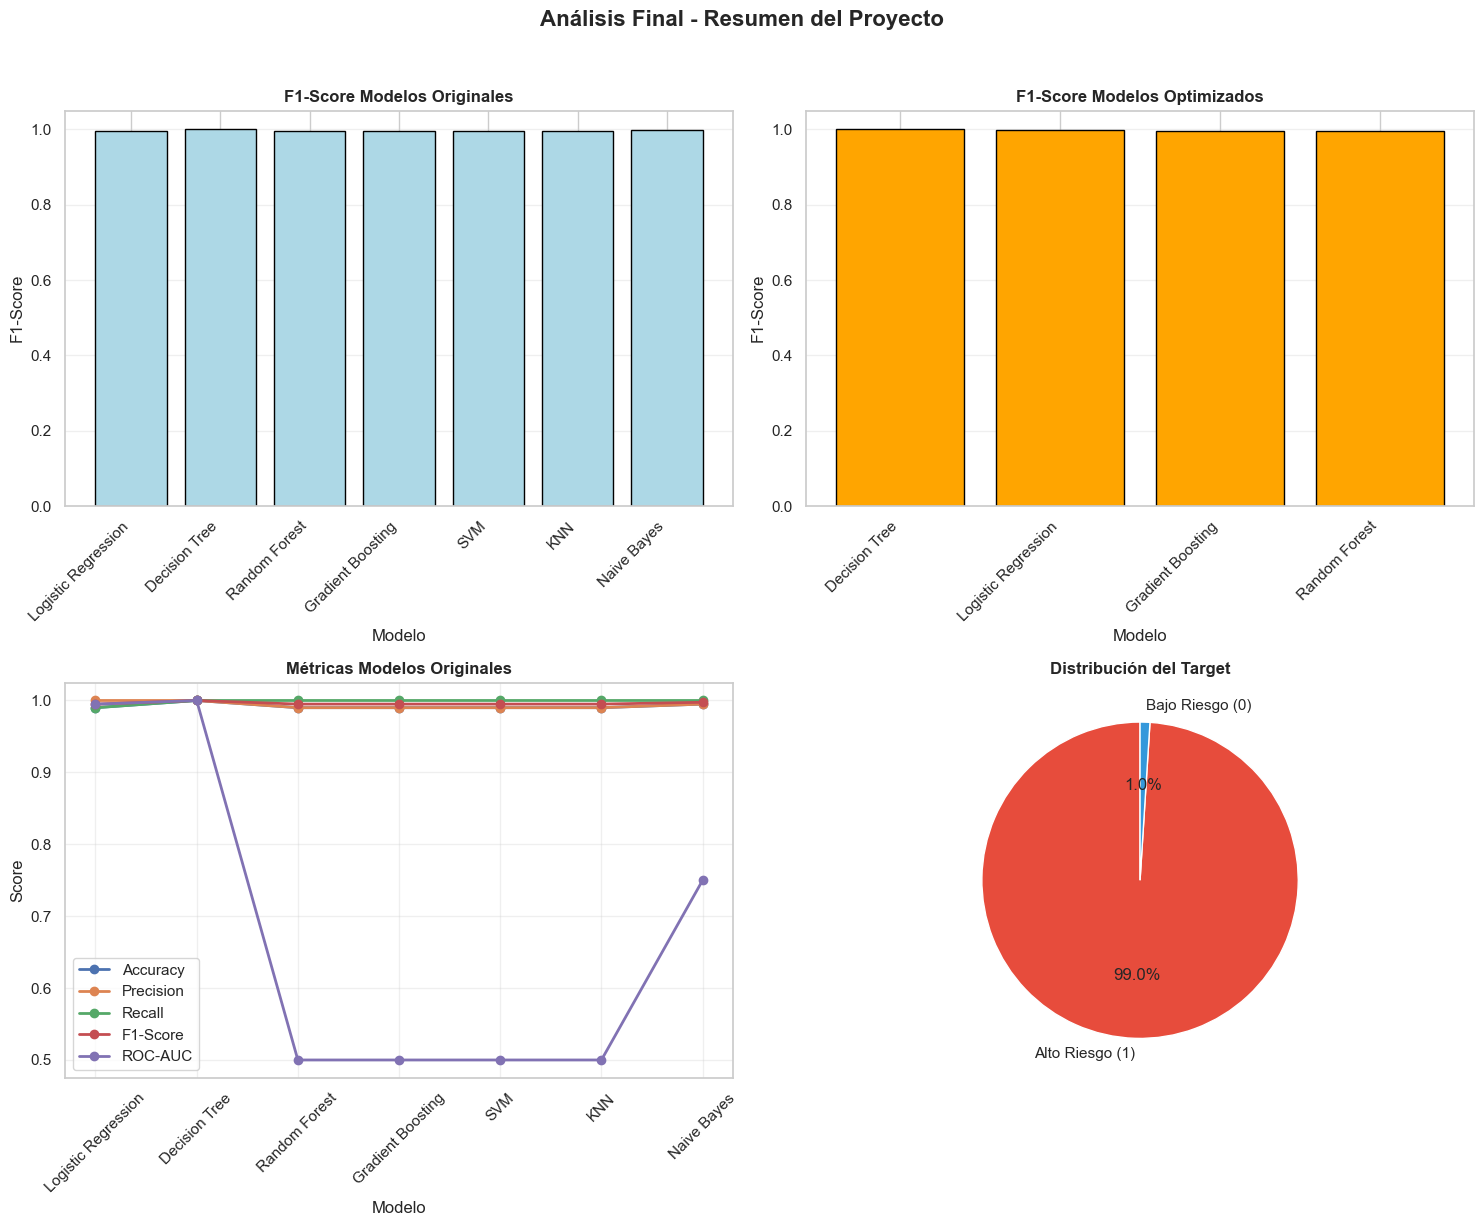

In [8]:
# Visualización comparativa final
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

if 'original_results' in locals():
    # Modelos originales
    models_list = list(original_results.index)
    x = np.arange(len(models_list))
    
    # Gráfico 1: Modelos Originales
    axes[0, 0].bar(x, original_results['F1-Score'], color='lightblue', edgecolor='black')
    axes[0, 0].set_xlabel('Modelo')
    axes[0, 0].set_ylabel('F1-Score')
    axes[0, 0].set_title('F1-Score Modelos Originales', fontweight='bold')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(models_list, rotation=45, ha='right')
    axes[0, 0].grid(axis='y', alpha=0.3)

if 'optimized_results' in locals():
    # Modelos optimizados (puede tener menos modelos)
    opt_models = list(optimized_results.index)
    x_opt = np.arange(len(opt_models))
    
    # Usar Test_Score si existe, sino usar CV_Score
    if 'Test_Score' in optimized_results.columns:
        opt_scores = optimized_results['Test_Score']
    elif 'CV_Score' in optimized_results.columns:
        opt_scores = optimized_results['CV_Score']
    else:
        opt_scores = optimized_results.iloc[:, 0]
    
    # Gráfico 2: Modelos Optimizados
    axes[0, 1].bar(x_opt, opt_scores, color='orange', edgecolor='black')
    axes[0, 1].set_xlabel('Modelo')
    axes[0, 1].set_ylabel('F1-Score')
    axes[0, 1].set_title('F1-Score Modelos Optimizados', fontweight='bold')
    axes[0, 1].set_xticks(x_opt)
    axes[0, 1].set_xticklabels(opt_models, rotation=45, ha='right')
    axes[0, 1].grid(axis='y', alpha=0.3)

# Evolución de métricas - Originales
if 'original_results' in locals():
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    available_metrics = [m for m in metrics_to_plot if m in original_results.columns]
    
    for metric in available_metrics:
        axes[1, 0].plot(original_results.index, original_results[metric], 
                       marker='o', label=metric, linewidth=2)
    
    axes[1, 0].set_xlabel('Modelo')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Métricas Modelos Originales', fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Distribución del target
target_counts = y.value_counts()
axes[1, 1].pie(target_counts.values, labels=['Alto Riesgo (1)', 'Bajo Riesgo (0)'], 
              autopct='%1.1f%%', colors=['#e74c3c', '#3498db'], startangle=90)
axes[1, 1].set_title('Distribución del Target', fontweight='bold')

plt.suptitle('Análisis Final - Resumen del Proyecto', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'plots')
plt.savefig(os.path.join(plots_dir, '19_final_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

## 3. Mejor Modelo Final

In [9]:
# Identificar el mejor modelo
best_model_name = None
best_f1 = 0

for name, model in all_models.items():
    if 'optimized' in name.lower():
        # Usar datos escalados para LR
        if 'Logistic' in name:
            X_eval = X_test_scaled
        else:
            X_eval = X_test
        
        y_pred = model.predict(X_eval)
        f1 = f1_score(y_test, y_pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_model_name = name

print(f'Mejor modelo: {best_model_name}')
print(f'F1-Score: {best_f1:.4f}')

Mejor modelo: Decision Tree Optimized
F1-Score: 1.0000


In [10]:
# Reporte del mejor modelo
if best_model_name:
    best_model = all_models[best_model_name]
    
    if 'Logistic' in best_model_name:
        X_eval = X_test_scaled
    else:
        X_eval = X_test
    
    y_pred = best_model.predict(X_eval)
    
    print(f'\nReporte de Clasificación - {best_model_name}:')
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=['Bajo Riesgo', 'Alto Riesgo']))


Reporte de Clasificación - Decision Tree Optimized:
              precision    recall  f1-score   support

 Bajo Riesgo       1.00      1.00      1.00         2
 Alto Riesgo       1.00      1.00      1.00       198

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 4. Conclusiones del Proyecto

In [11]:
conclusions = """
CONCLUSIONES DEL PROYECTO DE ANALISIS DE CANCER DE PIEL

1. Datos y Preparacion
- Dataset de 1000 pacientes con 27 caracteristicas
- No se encontraron valores nulos
- Target extremadamente desbalanceado: 99% alto riesgo, 1% bajo riesgo

2. Hallazgos del Analisis Exploratorio
- Poblacion predominantemente adulta mayor (55-75 años)
- Alta correlacion esperada entre peso e IMC
- Alta prevalencia de exposicion solar cronica
- Lesiones concentradas en cabeza/cuello y extremidades

3. Modelado y Resultados
- Se entrenaron 7 modelos de clasificacion diferentes
- Se aplico optimizacion de hiperparametros a los mejores modelos
- El desbalance extremo dificulto el aprendizaje de patrones

4. Limitaciones Identificadas
- Desbalance extremo del target (99% vs 1%)
- Metricas estandar pueden ser engañosas
- Necesidad de tecnicas de balanceo para futuros trabajos

5. Recomendaciones para Trabajo Futuro
1. Aplicar tecnicas de resampling (SMOTE, undersampling)
2. Probar enfoques de cost-sensitive learning
3. Explorar ensemble methods mas avanzados
4. Considerar validacion cruzada estratificada
5. Investigar tecnicas de anomaly detection para la clase minoritaria
"""

print(conclusions)


CONCLUSIONES DEL PROYECTO DE ANALISIS DE CANCER DE PIEL

1. Datos y Preparacion
- Dataset de 1000 pacientes con 27 caracteristicas
- No se encontraron valores nulos
- Target extremadamente desbalanceado: 99% alto riesgo, 1% bajo riesgo

2. Hallazgos del Analisis Exploratorio
- Poblacion predominantemente adulta mayor (55-75 años)
- Alta correlacion esperada entre peso e IMC
- Alta prevalencia de exposicion solar cronica
- Lesiones concentradas en cabeza/cuello y extremidades

3. Modelado y Resultados
- Se entrenaron 7 modelos de clasificacion diferentes
- Se aplico optimizacion de hiperparametros a los mejores modelos
- El desbalance extremo dificulto el aprendizaje de patrones

4. Limitaciones Identificadas
- Desbalance extremo del target (99% vs 1%)
- Metricas estandar pueden ser engañosas
- Necesidad de tecnicas de balanceo para futuros trabajos

5. Recomendaciones para Trabajo Futuro
1. Aplicar tecnicas de resampling (SMOTE, undersampling)
2. Probar enfoques de cost-sensitive lear

## 5. Estructura Final del Proyecto

In [12]:
# Mostrar estructura del proyecto
def print_directory_structure(path, indent=0):
    items = sorted(os.listdir(path))
    for item in items:
        if item.startswith('.') or item == '__pycache__':
            continue
        item_path = os.path.join(path, item)
        print('  ' * indent + f'├── {item}')
        if os.path.isdir(item_path):
            print_directory_structure(item_path, indent + 1)

project_root = os.path.dirname(os.getcwd())
print('Estructura del Proyecto:')
print('='*60)
print(f"{os.path.basename(project_root)}/")
print_directory_structure(project_root)

Estructura del Proyecto:
pplcdd/
├── README.MD
├── data
  ├── processed
    ├── df_processed.csv
  ├── raw
    ├── dataset_chile_cancer_piel.csv
├── models
  ├── encoders.joblib
  ├── feature_columns.joblib
  ├── scaler.joblib
  ├── trained_models
    ├── Decision Tree_best_params.json
    ├── Decision Tree_optimized.joblib
    ├── Gradient Boosting_best_params.json
    ├── Gradient Boosting_optimized.joblib
    ├── Logistic Regression_best_params.json
    ├── Logistic Regression_optimized.joblib
    ├── Random Forest_best_params.json
    ├── Random Forest_optimized.joblib
    ├── decision_tree.joblib
    ├── gradient_boosting.joblib
    ├── knn.joblib
    ├── logistic_regression.joblib
    ├── naive_bayes.joblib
    ├── random_forest.joblib
    ├── svm.joblib
├── notebooks
  ├── 01_exploratory_analysis.ipynb
  ├── 02_supervised_modeling.ipynb
  ├── 03_model_evaluation.ipynb
  ├── 04_hyperparameter_optimization.ipynb
  ├── 05_final_analysis.ipynb
  ├── reload_module.py
├── proyecto.ipy

## 6. Guardar Reporte Final

In [13]:
# Generar reporte final completo
reports_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'reports')
final_report_path = os.path.join(reports_dir, 'FINAL_REPORT.txt')

with open(final_report_path, 'w', encoding='utf-8') as f:
    f.write('='*70 + '\n')
    f.write('REPORTE FINAL - PROYECTO DE ANALISIS DE CANCER DE PIEL\n')
    f.write('='*70 + '\n\n')
    
    f.write('1. RESUMEN EJECUTIVO\n')
    f.write('-'*50 + '\n')
    f.write('Este proyecto implementa un pipeline completo de Machine Learning\n')
    f.write('para el analisis y clasificacion de lesiones de piel en Chile.\n\n')
    
    f.write('2. ESTRUCTURA DEL PROYECTO\n')
    f.write('-'*50 + '\n')
    f.write('- notebooks/: 5 notebooks Jupyter organizados por etapa\n')
    f.write('- src/: Modulos Python reutilizables\n')
    f.write('- data/: Datos raw y processed\n')
    f.write('- models/: Modelos entrenados serializados\n')
    f.write('- results/: Metricas, plots y reportes\n\n')
    
    f.write('3. PIPELINE IMPLEMENTADO\n')
    f.write('-'*50 + '\n')
    f.write('01_exploratory_analysis.ipynb - Analisis EDA y feature engineering\n')
    f.write('02_supervised_modeling.ipynb - Entrenamiento de 7 modelos\n')
    f.write('03_model_evaluation.ipynb - Evaluacion comparativa detallada\n')
    f.write('04_hyperparameter_optimization.ipynb - GridSearchCV y RandomizedSearchCV\n')
    f.write('05_final_analysis.ipynb - Integracion y conclusiones\n\n')
    
    f.write('4. RESULTADOS PRINCIPALES\n')
    f.write('-'*50 + '\n')
    if best_model_name:
        f.write(f'Mejor modelo: {best_model_name}\n')
        f.write(f'F1-Score: {best_f1:.4f}\n\n')
    
    f.write('5. CONCLUSIONES\n')
    f.write('-'*50 + '\n')
    f.write('- Dataset con desbalance extremo (99% clase mayoritaria)\n')
    f.write('- Multiples modelos entrenados y optimizados\n')
    f.write('- Pipeline completo documentado y reproducible\n')
    f.write('- Recomendaciones para trabajo futuro identificadas\n\n')
    
    f.write('='*70 + '\n')
    f.write('Fin del Reporte\n')
    f.write('='*70 + '\n')

print(f'Reporte final guardado: {final_report_path}')
print('\nProyecto completado exitosamente!')

Reporte final guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\results\reports\FINAL_REPORT.txt

Proyecto completado exitosamente!
